<div style="background:linear-gradient(135deg,#4338CA 0%,#7C3AED 55%,#EC4899 100%);border-radius:18px;padding:26px 29px;margin:15px 0 20px 0;">
<p style="color:#FBCFE8;font-size:14px;font-weight:bold;letter-spacing:1.4px;margin:0 0 9px 0;">WEEK 6 · DEEP LEARNING · DAY 3</p>
<h1 style="color:#FFFFFF;font-size:30px;margin:0 0 8px 0;">How Does a Neural Network Learn?</h1>
<p style="color:#EDE9FE;font-size:16px;margin:0;">Connecting backpropagation, gradient descent, and optimizers to heart disease prediction</p>
</div>
<div style="background:#F5F3FF;border:1px solid #DDD6FE;border-radius:14px;padding:17px 20px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;">On Day 1, I established a <b style="color:#2563EB;">Logistic Regression baseline</b>. On Day 2, I explored activations, forward propagation, and loss. Today, I will examine how a neural network can use its prediction errors to <b style="color:#059669;">update its weights</b> and improve over time.</p>
</div>
<div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:11px;padding:13px 16px;margin:14px 0;">
<p style="color:#1E3A8A;line-height:1.7;margin:0;"><b>Today's question:</b> How can a network learn from patient outcomes instead of repeating the same incorrect prediction?</p>
</div>
<div style="background:#FFF7ED;border:1px solid #FED7AA;border-radius:15px;padding:18px 21px;margin:18px 0;">
<h2 style="color:#C2410C;margin:0 0 12px 0;">What Will I Explore Today?</h2>
<p style="color:#374151;line-height:2;margin:0;">
<b style="color:#7C3AED;">01 — Project Connection:</b> Connect the lesson to the heart disease dataset and baseline.<br>
<b style="color:#DB2777;">02 — Training Loop:</b> Follow prediction, loss, backpropagation, and weight updates.<br>
<b style="color:#2563EB;">03 — Gradient Descent:</b> Understand how gradients guide the network toward lower loss.<br>
<b style="color:#059669;">04 — Learning Rate:</b> Compare slow, stable, and unstable training.<br>
<b style="color:#EA580C;">05 — Training Decisions:</b> Explain optimizers, epochs, batches, and the project baseline.
</p>
</div>
<div style="background:#F0F9FF;border-left:5px solid #0EA5E9;border-radius:12px;padding:16px 19px;margin:20px 0;">
<h2 style="color:#0369A1;margin:0 0 8px 0;">1. Starting with the Heart Disease Project</h2>
<p style="color:#374151;line-height:1.8;margin:0;">My project uses clinical patient features to predict whether heart disease is present. The goal today is not to replace the baseline with a finished neural network; it is to understand how that future network would learn.</p>
</div>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

np.random.seed(42)

<div style="background:#FDF2F8;border-left:5px solid #EC4899;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#BE185D;">Dataset note:</b> The notebook checks common dataset locations so it can reconnect to the same heart disease data used on Day 1 without depending on one fixed folder structure.</p>
</div>

In [ ]:
candidate_paths = [
    Path("heart.csv"),
    Path("../heart.csv"),
    Path("../day1/heart.csv"),
    Path("data/heart.csv"),
    Path("../day1/data/heart.csv")
]

dataset_path = next(
    (path for path in candidate_paths if path.exists()),
    None
)

if dataset_path is not None:
    heart_df = pd.read_csv(dataset_path)

    print("Dataset location:", dataset_path)
    print("Dataset shape:", heart_df.shape)
    print("Target column:", "HeartDisease")
else:
    heart_df = None

    print("Dataset not found in the expected folders.")
    print("Using the documented Day 1 project results for context.")

Dataset location: heart.csv
Dataset shape: (918, 12)
Target column: HeartDisease


In [ ]:
dataset_rows = len(heart_df) if heart_df is not None else 918

original_features = (
    heart_df.shape[1] - 1
    if heart_df is not None
    else 11
)

project_overview = pd.DataFrame({
    "Project Detail": [
        "Dataset records",
        "Original input features",
        "Features after preprocessing",
        "Training patients",
        "Testing patients",
        "Prediction task"
    ],
    "Value": [
        dataset_rows,
        original_features,
        21,
        734,
        184,
        "Binary classification"
    ]
})

project_overview

,Project Detail,Value
0,Dataset records,918
1,Original input features,11
2,Features after preprocessing,21
3,Training patients,734
4,Testing patients,184
5,Prediction task,Binary classification


<div style="background:#ECFDF5;border-left:5px solid #10B981;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#047857;">Project connection:</b> The dataset contains <b style="color:#7C3AED;">11 original features</b>. After encoding and preprocessing, the future network will receive <b style="color:#DB2777;">21 processed inputs</b>. Its output will represent the probability of heart disease.</p>
</div>

In [ ]:
patient_features = pd.DataFrame({
    "Feature": [
        "Age",
        "ChestPainType",
        "RestingBP",
        "Cholesterol",
        "MaxHR",
        "ExerciseAngina",
        "Oldpeak"
    ],
    "Meaning": [
        "Patient age",
        "Type of chest pain",
        "Resting blood pressure",
        "Serum cholesterol measurement",
        "Maximum heart rate achieved",
        "Chest pain triggered by exercise",
        "ST depression associated with exercise"
    ]
})

patient_features

,Feature,Meaning
0,Age,Patient age
1,ChestPainType,Type of chest pain
2,RestingBP,Resting blood pressure
3,Cholesterol,Serum cholesterol measurement
4,MaxHR,Maximum heart rate achieved
5,ExerciseAngina,Chest pain triggered by exercise
6,Oldpeak,ST depression associated with exercise


<div style="background:#FFF7ED;border-left:5px solid #F97316;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#C2410C;">Why this matters:</b> A prediction is not based on age or cholesterol alone. The network combines several measurements, compares its prediction with the known patient outcome, and adjusts its parameters when the prediction is wrong.</p>
</div>
<div style="background:#F5F3FF;border-left:5px solid #7C3AED;border-radius:12px;padding:16px 19px;margin:20px 0;">
<h2 style="color:#6D28D9;margin:0 0 8px 0;">2. Hands-On Step 1 — The Neural Network Training Loop</h2>
<p style="color:#374151;line-height:1.8;margin:0;">Training is a repeated cycle. The network predicts, measures the error, calculates gradients, and updates its weights before trying again.</p>
</div>
<div style="background:#EFF6FF;border:1px solid #BFDBFE;border-radius:14px;padding:18px 20px;margin:16px 0;text-align:center;">
<p style="font-size:17px;font-weight:bold;margin:0;line-height:2.2;">
<span style="color:#2563EB;">① Forward Pass</span> &nbsp;→&nbsp;
<span style="color:#DB2777;">② Compute Loss</span> &nbsp;→&nbsp;
<span style="color:#7C3AED;">③ Backpropagation</span> &nbsp;→&nbsp;
<span style="color:#059669;">④ Update Weights</span> &nbsp;↻
</p>
</div>

In [ ]:
training_loop = pd.DataFrame({
    "Step": [
        "1. Forward pass",
        "2. Compute loss",
        "3. Backpropagation",
        "4. Update weights"
    ],
    "What Happens": [
        "The network predicts the probability of heart disease.",
        "The prediction is compared with the patient's true label.",
        "Gradients show how each weight contributed to the error.",
        "The optimizer updates the weights to reduce future loss."
    ]
})

training_loop

,Step,What Happens
0,1. Forward pass,The network predicts the probability of heart ...
1,2. Compute loss,The prediction is compared with the patient's ...
2,3. Backpropagation,Gradients show how each weight contributed to ...
3,4. Update weights,The optimizer updates the weights to reduce fu...


<div style="background:#FDF2F8;border-left:5px solid #EC4899;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#BE185D;">Heart project example:</b> If the true label is <b style="color:#7C3AED;">1</b> but the network predicts only <b style="color:#2563EB;">0.20</b>, the prediction error is large. Backpropagation calculates how the weights contributed to that mistake, and the next update can move the prediction in a better direction.</p>
</div>
<div style="background:#ECFDF5;border-left:5px solid #10B981;border-radius:12px;padding:16px 19px;margin:20px 0;">
<h2 style="color:#047857;margin:0 0 8px 0;">3. Gradient Descent: Moving Toward Lower Loss</h2>
<p style="color:#374151;line-height:1.8;margin:0;">A gradient describes how a small change in a parameter affects the loss. Gradient descent moves the parameter in the opposite direction to reduce the error.</p>
</div>
<div style="background:#F5F3FF;border:1px solid #DDD6FE;border-radius:13px;padding:17px 20px;margin:15px 0;text-align:center;">
<p style="color:#6D28D9;font-size:19px;font-weight:bold;margin:0;">new_weight = old_weight − learning_rate × gradient</p>
</div>
<div style="background:#FFFBEB;border-left:5px solid #F59E0B;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#B45309;">Intuition:</b> Imagine standing on a hillside in fog. The gradient points toward increasing loss; moving in the opposite direction is like taking a downhill step. The learning rate determines the size of that step.</p>
</div>

In [ ]:
weight = 0.20
gradient = -0.377
learning_rate = 0.1

updated_weight = weight - learning_rate * gradient

weight_update = pd.DataFrame({
    "Quantity": [
        "Original weight",
        "Gradient",
        "Learning rate",
        "Updated weight"
    ],
    "Value": [
        weight,
        gradient,
        learning_rate,
        round(updated_weight, 4)
    ]
})

weight_update

,Quantity,Value
0,Original weight,0.2000
1,Gradient,-0.3770
2,Learning rate,0.1000
3,Updated weight,0.2377


<div style="background:#ECFDF5;border-left:5px solid #10B981;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#047857;">Observation:</b> The weight changes from <b style="color:#7C3AED;">0.20</b> to <b style="color:#DB2777;">0.2377</b>. Because the gradient is negative, subtracting it increases the weight. The gradient determines the direction, while the learning rate determines the step size.</p>
</div>
<div style="background:#FDF2F8;border-left:5px solid #EC4899;border-radius:12px;padding:16px 19px;margin:20px 0;">
<h2 style="color:#BE185D;margin:0 0 8px 0;">4. How Does the Learning Rate Change One Update?</h2>
<p style="color:#374151;line-height:1.8;margin:0;">Keeping the same weight and gradient makes it easier to isolate the effect of the learning rate.</p>
</div>

In [ ]:
learning_rates = [0.001, 0.1, 1.0]

update_comparison = pd.DataFrame({
    "Learning Rate": learning_rates,
    "Original Weight": [weight] * len(learning_rates),
    "Updated Weight": [
        round(weight - rate * gradient, 4)
        for rate in learning_rates
    ]
})

update_comparison

,Learning Rate,Original Weight,Updated Weight
0,0.001,0.2,0.2004
1,0.100,0.2,0.2377
2,1.000,0.2,0.5770


<div style="background:#FFFBEB;border-left:5px solid #F59E0B;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#B45309;">Observation:</b> A smaller learning rate produces a smaller update, while a larger learning rate moves the weight farther. This table explains step size, but it does not prove which learning rate is best; that requires observing the loss over repeated training steps.</p>
</div>
<div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:12px;padding:16px 19px;margin:20px 0;">
<h2 style="color:#1D4ED8;margin:0 0 8px 0;">5. Preparing a Tiny Binary-Classification Experiment</h2>
<p style="color:#374151;line-height:1.8;margin:0;">I will use a small, controlled example to make every forward pass, gradient, and weight update visible.</p>
</div>
<div style="background:#FFFBEB;border-left:4px solid #F59E0B;border-radius:10px;padding:12px 15px;margin:13px 0;">
<p style="color:#92400E;line-height:1.7;margin:0;"><b>Important distinction:</b> These six rows are an educational example, not actual patient measurements. Their loss values are not the heart disease project's evaluation results.</p>
</div>

In [ ]:
X_tiny = np.array([
    [0.10, 0.20],
    [0.20, 0.30],
    [0.30, 0.20],
    [0.70, 0.80],
    [0.80, 0.70],
    [0.90, 0.90]
])

y_tiny = np.array([
    [0],
    [0],
    [0],
    [1],
    [1],
    [1]
])

tiny_dataset = pd.DataFrame({
    "Input 1": X_tiny[:, 0],
    "Input 2": X_tiny[:, 1],
    "Target": y_tiny.ravel()
})

tiny_dataset

,Input 1,Input 2,Target
0,0.1,0.2,0
1,0.2,0.3,0
2,0.3,0.2,0
3,0.7,0.8,1
4,0.8,0.7,1
5,0.9,0.9,1


<div style="background:#F5F3FF;border-left:5px solid #8B5CF6;border-radius:12px;padding:16px 19px;margin:20px 0;">
<h2 style="color:#6D28D9;margin:0 0 8px 0;">6. Choosing Activation and Loss Functions</h2>
<p style="color:#374151;line-height:1.8;margin:0;">The hidden layer uses ReLU, the output layer uses Sigmoid, and Binary Cross-Entropy measures the error. These choices match the project's binary classification task.</p>
</div>

In [ ]:
network_choices = pd.DataFrame({
    "Component": [
        "Hidden activation",
        "Output activation",
        "Loss function"
    ],
    "Choice": [
        "ReLU",
        "Sigmoid",
        "Binary Cross-Entropy"
    ],
    "Reason": [
        "Adds non-linearity to the hidden layer.",
        "Produces a probability between 0 and 1.",
        "Measures binary prediction error."
    ]
})

network_choices

,Component,Choice,Reason
0,Hidden activation,ReLU,Adds non-linearity to the hidden layer.
1,Output activation,Sigmoid,Produces a probability between 0 and 1.
2,Loss function,Binary Cross-Entropy,Measures binary prediction error.


In [ ]:
def relu(values):
    return np.maximum(0, values)


def sigmoid(values):
    values = np.clip(values, -500, 500)
    return 1 / (1 + np.exp(-values))


def binary_cross_entropy(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)

    return -np.mean(
        y_true * np.log(y_pred)
        + (1 - y_true) * np.log(1 - y_pred)
    )

<div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#1D4ED8;">Numerical stability:</b> Clipping avoids invalid calculations such as <b>log(0)</b> and limits extremely large values inside the exponential function.</p>
</div>
<div style="background:#ECFDF5;border-left:5px solid #10B981;border-radius:12px;padding:16px 19px;margin:20px 0;">
<h2 style="color:#047857;margin:0 0 8px 0;">7. Building the Demonstration Network</h2>
<p style="color:#374151;line-height:1.8;margin:0;">The small network has two inputs, four hidden neurons, and one output probability.</p>
</div>
<div style="background:#F5F3FF;border:1px solid #DDD6FE;border-radius:12px;padding:15px 18px;margin:14px 0;text-align:center;">
<p style="color:#6D28D9;font-size:18px;font-weight:bold;margin:0;">2 Inputs → 4 Hidden Neurons → 1 Output</p>
</div>

In [ ]:
rng = np.random.default_rng(42)

W1 = rng.normal(0, 0.5, size=(2, 4))
b1 = np.zeros((1, 4))

W2 = rng.normal(0, 0.5, size=(4, 1))
b2 = np.zeros((1, 1))

network_parameters = pd.DataFrame({
    "Parameter": ["W1", "b1", "W2", "b2"],
    "Role": [
        "Input-to-hidden weights",
        "Hidden-layer biases",
        "Hidden-to-output weights",
        "Output-layer bias"
    ],
    "Shape": [
        str(W1.shape),
        str(b1.shape),
        str(W2.shape),
        str(b2.shape)
    ],
    "Values": [W1.size, b1.size, W2.size, b2.size]
})

network_parameters

,Parameter,Role,Shape,Values
0,W1,Input-to-hidden weights,"(2, 4)",8
1,b1,Hidden-layer biases,"(1, 4)",4
2,W2,Hidden-to-output weights,"(4, 1)",4
3,b2,Output-layer bias,"(1, 1)",1


In [ ]:
total_parameters = W1.size + b1.size + W2.size + b2.size

print("Total trainable parameters:", total_parameters)

Total trainable parameters: 17


<div style="background:#FFFBEB;border-left:5px solid #F59E0B;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#B45309;">Observation:</b> The demonstration network contains <b style="color:#7C3AED;">17 trainable parameters</b>: 8 first-layer weights, 4 hidden biases, 4 output weights, and 1 output bias. Training changes these values, not the patient labels.</p>
</div>
<div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:12px;padding:16px 19px;margin:20px 0;">
<h2 style="color:#1D4ED8;margin:0 0 8px 0;">8. The First Forward Pass</h2>
<p style="color:#374151;line-height:1.8;margin:0;">Before updating anything, I will pass the inputs through the network and calculate the initial prediction error.</p>
</div>

In [ ]:
hidden_values = X_tiny @ W1 + b1
hidden_output = relu(hidden_values)

output_values = hidden_output @ W2 + b2
predictions = sigmoid(output_values)

initial_loss = binary_cross_entropy(y_tiny, predictions)

initial_predictions = pd.DataFrame({
    "Actual Target": y_tiny.ravel(),
    "Predicted Probability": predictions.round(3).ravel()
})

initial_predictions

,Actual Target,Predicted Probability
0,0,0.507
1,0,0.515
2,0,0.524
3,1,0.554
4,1,0.563
5,1,0.570


In [ ]:
print("Hidden layer shape:", hidden_output.shape)
print("Initial loss:", round(initial_loss, 4))

Hidden layer shape: (6, 4)
Initial loss: 0.65


<div style="background:#FDF2F8;border-left:5px solid #EC4899;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#BE185D;">Reading the result:</b> The network starts with random weights, so its first probabilities are not expected to be accurate. The initial loss becomes the reference for checking whether the first update improves the predictions.</p>
</div>
<div style="background:#FDF2F8;border-left:5px solid #EC4899;border-radius:12px;padding:16px 19px;margin:20px 0;">
<h2 style="color:#BE185D;margin:0 0 8px 0;">9. Backpropagation: Tracing the Error Backward</h2>
<p style="color:#374151;line-height:1.8;margin:0;">Backpropagation starts at the loss and works backward through the network to calculate a gradient for every weight and bias.</p>
</div>
<div style="background:#F5F3FF;border:1px solid #DDD6FE;border-radius:13px;padding:17px 20px;margin:15px 0;text-align:center;">
<p style="color:#6D28D9;font-size:17px;font-weight:bold;margin:0;line-height:2;">Loss → Output Layer → Hidden Layer → Input Weights</p>
</div>
<div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#1D4ED8;">Why the chain rule?</b> An early weight changes the hidden activation, which changes the output, which changes the loss. The chain rule connects these dependent changes so the network can calculate how that weight influenced the final error.</p>
</div>
<div style="background:#FFFFFF;border:1px solid #E5E7EB;border-radius:12px;padding:15px 18px;margin:15px 0;text-align:center;">
<p style="color:#6D28D9;font-size:16px;font-weight:bold;margin:0;">∂Loss / ∂Weight = (∂Loss / ∂Output) × (∂Output / ∂Weight)</p>
</div>

In [ ]:
sample_count = len(X_tiny)

output_error = predictions - y_tiny

dW2 = hidden_output.T @ output_error / sample_count
db2 = np.mean(output_error, axis=0, keepdims=True)

hidden_error = output_error @ W2.T
hidden_error = hidden_error * (hidden_values > 0)

dW1 = X_tiny.T @ hidden_error / sample_count
db1 = np.mean(hidden_error, axis=0, keepdims=True)

gradient_summary = pd.DataFrame({
    "Gradient": ["dW1", "db1", "dW2", "db2"],
    "Shape": [
        str(dW1.shape),
        str(db1.shape),
        str(dW2.shape),
        str(db2.shape)
    ],
    "Parameter": ["W1", "b1", "W2", "b2"]
})

gradient_summary

,Gradient,Shape,Parameter
0,dW1,"(2, 4)",W1
1,db1,"(1, 4)",b1
2,dW2,"(4, 1)",W2
3,db2,"(1, 1)",b2


<div style="background:#FFF7ED;border-left:5px solid #F97316;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#C2410C;">A useful detail:</b> With a Sigmoid output and Binary Cross-Entropy loss, the output-layer error simplifies to <b>prediction − target</b>. The expression <b>hidden_values &gt; 0</b> applies the derivative of ReLU.</p>
</div>
<div style="background:#ECFDF5;border-left:5px solid #10B981;border-radius:12px;padding:15px 18px;margin:18px 0;">
<h3 style="color:#047857;margin:0 0 7px 0;">Applying One Weight Update</h3>
<p style="color:#374151;line-height:1.8;margin:0;">After calculating the gradients, I will update every parameter and check whether the loss decreases.</p>
</div>

In [ ]:
learning_rate = 0.1

W1_updated = W1 - learning_rate * dW1
b1_updated = b1 - learning_rate * db1

W2_updated = W2 - learning_rate * dW2
b2_updated = b2 - learning_rate * db2

updated_hidden = relu(X_tiny @ W1_updated + b1_updated)

updated_predictions = sigmoid(
    updated_hidden @ W2_updated + b2_updated
)

updated_loss = binary_cross_entropy(
    y_tiny,
    updated_predictions
)

update_result = pd.DataFrame({
    "Stage": ["Before the update", "After the update"],
    "Binary Cross-Entropy": [
        round(initial_loss, 4),
        round(updated_loss, 4)
    ]
})

update_result

,Stage,Binary Cross-Entropy
0,Before the update,0.6500
1,After the update,0.6483


<div style="background:#F5F3FF;border-left:5px solid #8B5CF6;border-radius:12px;padding:16px 19px;margin:20px 0;">
<h2 style="color:#6D28D9;margin:0 0 8px 0;">10. Repeating the Complete Training Loop</h2>
<p style="color:#374151;line-height:1.8;margin:0;">One update is not enough. The following function repeats the forward pass, loss calculation, backpropagation, and weight updates for multiple epochs.</p>
</div>

In [ ]:
def train_tiny_network(learning_rate, epochs=200):

    rng = np.random.default_rng(42)

    W1 = rng.normal(0, 0.5, size=(2, 4))
    b1 = np.zeros((1, 4))

    W2 = rng.normal(0, 0.5, size=(4, 1))
    b2 = np.zeros((1, 1))

    loss_history = []

    for _ in range(epochs):

        hidden_values = X_tiny @ W1 + b1
        hidden_output = relu(hidden_values)

        predictions = sigmoid(hidden_output @ W2 + b2)
        loss_history.append(
            binary_cross_entropy(y_tiny, predictions)
        )

        output_error = predictions - y_tiny

        dW2 = hidden_output.T @ output_error / len(X_tiny)
        db2 = np.mean(output_error, axis=0, keepdims=True)

        hidden_error = output_error @ W2.T
        hidden_error *= hidden_values > 0

        dW1 = X_tiny.T @ hidden_error / len(X_tiny)
        db1 = np.mean(hidden_error, axis=0, keepdims=True)

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2

    return np.array(loss_history)

<div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#1D4ED8;">Fair comparison:</b> The random generator is reset inside the function. This gives each learning-rate experiment the same initial weights, architecture, data, and number of epochs.</p>
</div>
<div style="background:#FFF7ED;border-left:5px solid #F97316;border-radius:12px;padding:16px 19px;margin:20px 0;">
<h2 style="color:#C2410C;margin:0 0 8px 0;">11. Hands-On Step 2 — Comparing Three Learning Rates</h2>
<p style="color:#374151;line-height:1.8;margin:0;">The same demonstration network is trained with a very small, moderate, and very large learning rate.</p>
</div>

In [ ]:
low_rate_loss = train_tiny_network(learning_rate=0.001)
medium_rate_loss = train_tiny_network(learning_rate=0.1)
high_rate_loss = train_tiny_network(learning_rate=5.0)

learning_rate_results = pd.DataFrame({
    "Learning Rate": [0.001, 0.1, 5.0],
    "Final Loss": [
        round(low_rate_loss[-1], 4),
        round(medium_rate_loss[-1], 4),
        round(high_rate_loss[-1], 4)
    ],
    "Observed Behavior": [
        "Slow progress",
        "Stable improvement",
        "Unstable learning"
    ]
})

learning_rate_results

,Learning Rate,Final Loss,Observed Behavior
0,0.001,0.6467,Slow progress
1,0.100,0.1418,Stable improvement
2,5.000,0.6931,Unstable learning


<div style="background:#ECFDF5;border-left:5px solid #10B981;border-radius:11px;padding:15px 18px;margin:16px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#047857;">Observation:</b> The learning rate <b style="color:#2563EB;">0.001</b> leaves the loss near <b>0.6467</b>. The moderate rate <b style="color:#059669;">0.1</b> reduces it to <b>0.1418</b>. The large rate <b style="color:#DB2777;">5.0</b> becomes unstable and finishes near <b>0.6931</b>.</p>
</div>

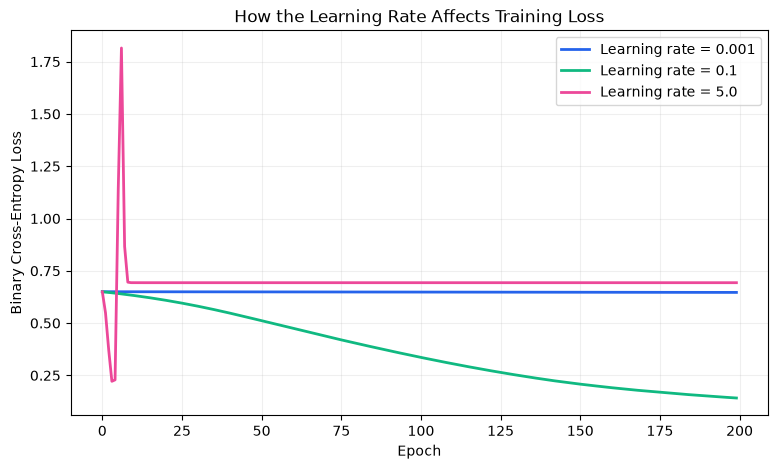

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    low_rate_loss,
    label="Learning rate = 0.001",
    color="#2563EB",
    linewidth=2
)

plt.plot(
    medium_rate_loss,
    label="Learning rate = 0.1",
    color="#10B981",
    linewidth=2
)

plt.plot(
    high_rate_loss,
    label="Learning rate = 5.0",
    color="#EC4899",
    linewidth=2
)

plt.title("How the Learning Rate Affects Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

<div style="background:#F5F3FF;border-left:5px solid #8B5CF6;border-radius:12px;padding:16px 19px;margin:16px 0;">
<p style="color:#374151;line-height:1.9;margin:0;"><b style="color:#6D28D9;">Reading the plot:</b> The <b style="color:#2563EB;">blue curve</b> stays almost flat because its updates are too small. The <b style="color:#059669;">green curve</b> decreases smoothly, showing stable learning. The <b style="color:#DB2777;">pink curve</b> jumps sharply and settles near 0.693, indicating that large updates disrupted the training process.</p>
</div>
<div style="background:#FFFBEB;border-left:5px solid #F59E0B;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#B45309;">Why is 0.693 important?</b> Binary Cross-Entropy for a probability of 0.5 is approximately <b>−log(0.5) = 0.693</b>. For this balanced demonstration, that value is consistent with predictions that are no better than an uninformative 50% probability.</p>
</div>

In [ ]:
uninformative_loss = -np.log(0.5)

print(
    "Binary cross-entropy at probability 0.5:",
    round(uninformative_loss, 4)
)

Binary cross-entropy at probability 0.5: 0.6931


<div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:12px;padding:16px 19px;margin:20px 0;">
<h2 style="color:#1D4ED8;margin:0 0 9px 0;">12. Understanding Epochs, Batches, and Updates</h2>
<p style="color:#374151;line-height:1.8;margin:0;">An epoch is one complete pass through the training data. A batch is the group of samples processed before one parameter update.</p>
</div>

In [ ]:
training_terms = pd.DataFrame({
    "Term": ["Epoch", "Batch", "Gradient", "Optimizer"],
    "Meaning": [
        "One complete pass through all training samples.",
        "A subset of samples used before one update.",
        "The direction in which the loss changes.",
        "The algorithm that updates the model parameters."
    ]
})

training_terms

,Term,Meaning
0,Epoch,One complete pass through all training samples.
1,Batch,A subset of samples used before one update.
2,Gradient,The direction in which the loss changes.
3,Optimizer,The algorithm that updates the model parameters.


In [ ]:
training_samples = 734
batch_size = 32
epochs = 10

batches_per_epoch = int(
    np.ceil(training_samples / batch_size)
)

total_updates = batches_per_epoch * epochs

batch_summary = pd.DataFrame({
    "Training Detail": [
        "Training patients",
        "Batch size",
        "Batches per epoch",
        "Epochs",
        "Total updates"
    ],
    "Value": [
        training_samples,
        batch_size,
        batches_per_epoch,
        epochs,
        total_updates
    ]
})

batch_summary

,Training Detail,Value
0,Training patients,734
1,Batch size,32
2,Batches per epoch,23
3,Epochs,10
4,Total updates,230


<div style="background:#F0FDF4;border-left:5px solid #22C55E;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#15803D;">Project example:</b> Dividing <b>734 training patients</b> into batches of <b>32</b> requires <b>23 batches per epoch</b>. Over <b>10 epochs</b>, the network would perform <b>230 parameter updates</b>. The last batch contains the remaining patients.</p>
</div>
<div style="background:#FFFBEB;border-left:5px solid #F59E0B;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#B45309;">Important distinction:</b> The NumPy demonstration above processes all six examples together, so it uses <b>full-batch gradient descent</b>. The 32-patient calculation illustrates a possible future <b>mini-batch</b> training setup for the real project.</p>
</div>
<div style="background:#FFF7ED;border-left:5px solid #F97316;border-radius:12px;padding:16px 19px;margin:20px 0;">
<h2 style="color:#C2410C;margin:0 0 9px 0;">13. Comparing SGD and Adam</h2>
<p style="color:#374151;line-height:1.8;margin:0;">Backpropagation computes the gradients. The optimizer decides how to use those gradients when updating the weights and biases.</p>
</div>

In [ ]:
optimizer_comparison = pd.DataFrame({
    "Optimizer": ["SGD", "Adam"],
    "Update Strategy": [
        "Updates parameters using the gradient and a chosen learning rate.",
        "Adapts updates using running estimates of gradient behavior."
    ],
    "Practical Note": [
        "Simple and useful for understanding basic updates.",
        "A common starting choice for neural network training."
    ]
})

optimizer_comparison

,Optimizer,Update Strategy,Practical Note
0,SGD,Updates parameters using the gradient and a ch...,Simple and useful for understanding basic upda...
1,Adam,Adapts updates using running estimates of grad...,A common starting choice for neural network tr...


<div style="background:#FDF2F8;border-left:5px solid #EC4899;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#BE185D;">Research note:</b> TensorFlow's Adam optimizer uses <b>0.001</b> as its default learning rate. Adam keeps running estimates related to both the gradient and its squared value, allowing different parameters to receive differently scaled updates.</p>
</div>
<div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#1D4ED8;">Do not mix the experiments:</b> A learning rate of <b>0.1</b> worked best for this tiny manual gradient-descent demonstration. That does not mean 0.1 is automatically the best choice for the real project or for Adam, which uses a different update strategy.</p>
</div>
<div style="background:#F5F3FF;border-left:5px solid #8B5CF6;border-radius:12px;padding:16px 19px;margin:20px 0;">
<h2 style="color:#6D28D9;margin:0 0 9px 0;">14. Hands-On Step 3 — Explaining Backpropagation</h2>
<p style="color:#374151;line-height:1.8;margin:0;">Backpropagation starts with the final prediction error and traces that error backward through the network. It calculates how much each weight and bias contributed to the loss. The chain rule is needed because the effect of an early weight passes through several connected calculations before reaching the final prediction.</p>
</div>
<div style="background:#ECFDF5;border-left:5px solid #10B981;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#047857;">In the heart disease project:</b> If the model misses a real heart disease case, backpropagation identifies how its current parameters contributed to that incorrect probability. The optimizer can then adjust those parameters during training.</p>
</div>
<div style="background:#F0F9FF;border-left:5px solid #0EA5E9;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#0369A1;">How frameworks do this:</b> TensorFlow provides <b>GradientTape</b>, while PyTorch provides <b>autograd</b>. Both can compute gradients automatically; this notebook calculates them manually only to make the learning process understandable.</p>
</div>
<div style="background:#FDF2F8;border-left:5px solid #EC4899;border-radius:12px;padding:16px 19px;margin:20px 0;">
<h2 style="color:#BE185D;margin:0 0 9px 0;">15. Connecting the Architecture to the Heart Disease Project</h2>
<p style="color:#374151;line-height:1.8;margin:0;">The demonstration network is intentionally small. The planned project network uses the 21 processed patient features identified on Day 1.</p>
</div>
<div style="background:#F5F3FF;border:1px solid #DDD6FE;border-radius:12px;padding:15px 18px;margin:14px 0;text-align:center;">
<p style="color:#6D28D9;font-size:18px;font-weight:bold;margin:0;">21 Inputs → 16 Hidden Neurons → 8 Hidden Neurons → 1 Output</p>
</div>

In [ ]:
project_architecture = pd.DataFrame({
    "Layer": ["Input", "Hidden 1", "Hidden 2", "Output"],
    "Units": [21, 16, 8, 1],
    "Activation": ["—", "ReLU", "ReLU", "Sigmoid"],
    "Role": [
        "Receives the processed patient features.",
        "Learns the first patient-feature combinations.",
        "Learns additional non-linear patterns.",
        "Produces the heart disease probability."
    ]
})

project_architecture

,Layer,Units,Activation,Role
0,Input,21,—,Receives the processed patient features.
1,Hidden 1,16,ReLU,Learns the first patient-feature combinations.
2,Hidden 2,8,ReLU,Learns additional non-linear patterns.
3,Output,1,Sigmoid,Produces the heart disease probability.


In [ ]:
layer_1_parameters = 21 * 16 + 16
layer_2_parameters = 16 * 8 + 8
output_parameters = 8 * 1 + 1

project_parameter_count = (
    layer_1_parameters
    + layer_2_parameters
    + output_parameters
)

parameter_breakdown = pd.DataFrame({
    "Connection": [
        "21 inputs → 16 neurons",
        "16 neurons → 8 neurons",
        "8 neurons → 1 output"
    ],
    "Trainable Parameters": [
        layer_1_parameters,
        layer_2_parameters,
        output_parameters
    ]
})

parameter_breakdown

,Connection,Trainable Parameters
0,21 inputs → 16 neurons,352
1,16 neurons → 8 neurons,136
2,8 neurons → 1 output,9


In [ ]:
print(
    "Total trainable parameters in the proposed architecture:",
    project_parameter_count
)

Total trainable parameters in the proposed architecture: 497


<div style="background:#FFF7ED;border-left:5px solid #F97316;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#C2410C;">Observation:</b> The proposed architecture contains <b>497 trainable parameters</b>. Backpropagation would calculate gradients for these parameters, and an optimizer such as Adam would update them during training.</p>
</div>
<div style="background:#ECFDF5;border-left:5px solid #10B981;border-radius:12px;padding:16px 19px;margin:20px 0;">
<h2 style="color:#047857;margin:0 0 9px 0;">16. The Baseline the Future Network Must Beat</h2>
<p style="color:#374151;line-height:1.8;margin:0;">A lower training loss alone does not prove that the neural network is better. Its future evaluation must be compared with the existing Logistic Regression baseline on unseen patients.</p>
</div>

In [ ]:
baseline_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Day 1 Logistic Regression Baseline": [
        0.886,
        0.886,
        0.912,
        0.899
    ]
})

baseline_results

,Metric,Day 1 Logistic Regression Baseline
0,Accuracy,0.886
1,Precision,0.886
2,Recall,0.912
3,F1-score,0.899


<div style="background:#EFF6FF;border-left:5px solid #3B82F6;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#1D4ED8;">Evaluation rule:</b> The project network will be assessed using the same evaluation approach as the baseline. <b style="color:#7C3AED;">F1-score = 0.899</b> and <b style="color:#DB2777;">Recall = 0.912</b> are the reference values. Recall is particularly important because a false negative means missing a real heart disease case.</p>
</div>
<div style="background:#FFFBEB;border-left:5px solid #F59E0B;border-radius:11px;padding:14px 17px;margin:15px 0;">
<p style="color:#374151;line-height:1.8;margin:0;"><b style="color:#B45309;">Limitation:</b> A decreasing training loss does not guarantee good performance on new patients. A future model can still overfit, so validation results and the held-out test set must also be examined.</p>
</div>
<div style="background:#FFF7ED;border-left:5px solid #F97316;border-radius:12px;padding:16px 19px;margin:20px 0;">
<h2 style="color:#C2410C;margin:0 0 9px 0;">17. Hands-On Step 4 — Mentor Review and Pull Request</h2>
<p style="color:#374151;line-height:1.8;margin:0;">After reviewing the notebook, I will commit the Day 3 work to the appropriate project branch and open a pull request for mid-sprint mentor feedback.</p>
</div>

In [ ]:
hands_on_checklist = pd.DataFrame({
    "Hands-On Requirement": [
        "Describe the four-step training loop.",
        "Compare three learning rates and plot the loss curves.",
        "Explain backpropagation and the chain rule.",
        "Open a pull request for mentor review."
    ],
    "Where It Appears": [
        "Section 2",
        "Section 11",
        "Sections 9 and 14",
        "GitHub workflow after saving this notebook"
    ]
})

hands_on_checklist

,Hands-On Requirement,Where It Appears
0,Describe the four-step training loop.,Section 2
1,Compare three learning rates and plot the loss...,Section 11
2,Explain backpropagation and the chain rule.,Sections 9 and 14
3,Open a pull request for mentor review.,GitHub workflow after saving this notebook


<div style="background:#F5F3FF;border-left:5px solid #8B5CF6;border-radius:12px;padding:16px 19px;margin:20px 0;">
<h2 style="color:#6D28D9;margin:0 0 9px 0;">Research and Official References</h2>
<p style="color:#374151;line-height:1.9;margin:0;">I used official framework documentation and the original Adam research paper to connect the manual NumPy experiment to how real deep-learning tools compute gradients and update model parameters.</p>
</div>

-   [TensorFlow: Introduction to Gradients and Automatic
    Differentiation](https://www.tensorflow.org/guide/autodiff)
-   [TensorFlow: Adam Optimizer and Default Learning
    Rate](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam)
-   [PyTorch: Automatic Differentiation with
    torch.autograd](https://docs.pytorch.org/tutorials/beginner/basics/autograd_tutorial.html)
-   [Kingma and Ba: Adam: A Method for Stochastic
    Optimization](https://arxiv.org/abs/1412.6980)

<div style="background:linear-gradient(135deg,#4338CA 0%,#7C3AED 55%,#EC4899 100%);border-radius:15px;padding:19px 22px;margin:22px 0;">
<h2 style="color:#FFFFFF;margin:0 0 11px 0;">Day 3 — Final Takeaways</h2>
<p style="color:#F5F3FF;line-height:2;margin:0;">
Training repeats <b>forward pass → loss → backpropagation → weight update.</b><br>
The learning rate controls how far each parameter moves.<br>
The demonstration achieved its lowest final loss, <b>0.1418</b>, with a learning rate of <b>0.1</b>.<br>
Backpropagation calculates gradients, while the optimizer uses them to update the parameters.<br>
The proposed heart disease network has <b>21 inputs</b> and <b>497 trainable parameters</b>.<br>
Any future model must be compared with the baseline <b>F1-score of 0.899</b> and <b>Recall of 0.912</b>.
</p>
</div>